<a href="https://colab.research.google.com/github/irene-ch-yeh/colab/blob/main/ntuhw2_wistron_irene_Pb2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane pennylane --upgrade
!pip install networkx matplotlib scipy neal dwave-ocean-sdk

  Using cached pennylane-0.44.1-py3-none-any.whl.metadata (12 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 76.3 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement neal (from versions: none)
ERROR: No matching distribution found for neal


In [ ]:
!pip install dimod dwave-neal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 55.5 MB/s eta 0:00:00


Part (a): Graph Generation + Brute Force Max-Cut
Nodes: 8, Edges: 9
Edges: [(0, 2), (0, 5), (0, 6), (1, 5), (2, 3), (3, 5), (4, 5), (5, 7), (6, 7)]

Maximum cut value: 9
Number of optimal partitions: 2
  Set 0=[0, 1, 3, 4, 7], Set 1=[2, 5, 6]
  Set 0=[2, 5, 6], Set 1=[0, 1, 3, 4, 7]
Brute force time: 0.000238 s

[Graph saved to p2_graph.png]


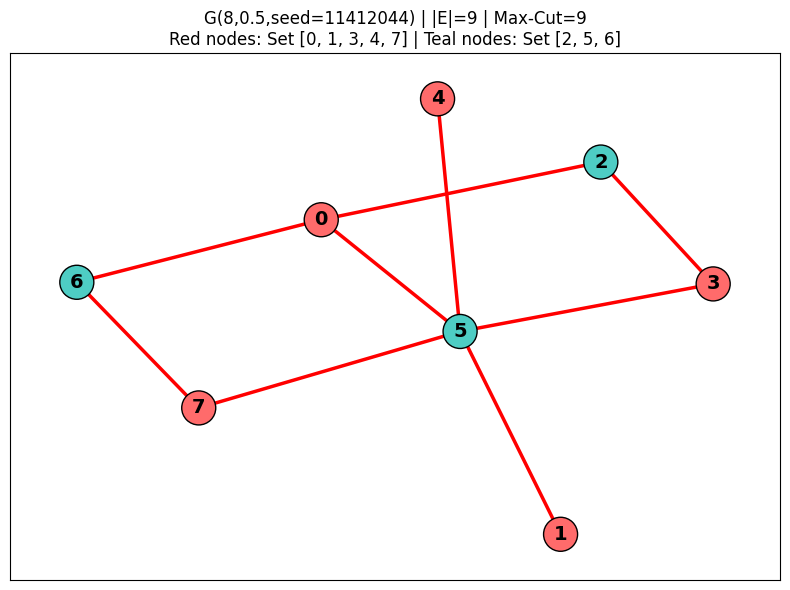


Part (b): QAOA p=1 Energy Landscape
Computing landscape (50×50 grid)...
Landscape computed in 60.7 s
Grid global minimum: γ*=5.6420, β*=0.3847
⟨H_C⟩_min = -6.3533  →  Expected cut = 6.3533
Exact max-cut = 9
p=1 grid approx ratio = 0.7059
[Landscape saved to p2_landscape.png]


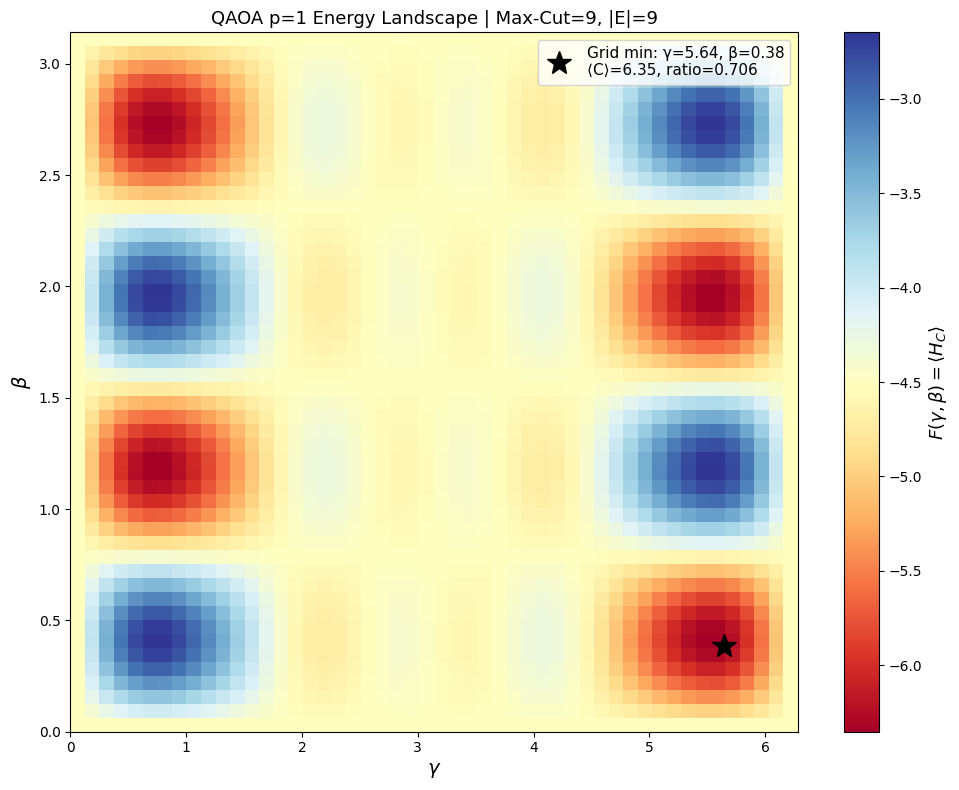


Optimizer reliability test (20 random inits, COBYLA):
  Expected cut ⟨C⟩: mean=5.5353 ± 0.8309
  Best ⟨C⟩ found: 6.3658
  Reached grid global (±0.1): 10/20 (50%)

Part (c): QAOA for p = 1, 2, 3, 4

--- Optimizing QAOA p=1 (2 params, 20 random inits) ---
  Expected cut ⟨C⟩ = 6.3658
  Most probable bitstring: [0, 0, 1, 0, 0, 1, 1, 0] (prob=0.0568, cut=9)
  Approx ratio (⟨C⟩/C*) = 0.7073
  γ = [6.9804]
  β = [2.7489]
  Time: 20.87 s

--- Optimizing QAOA p=2 (4 params, 20 random inits) ---
  Expected cut ⟨C⟩ = 7.3092
  Most probable bitstring: [0, 0, 1, 0, 0, 1, 1, 0] (prob=0.1819, cut=9)
  Approx ratio (⟨C⟩/C*) = 0.8121
  γ = [6.8323, 0.8754]
  β = [1.0641, 1.2520]
  Time: 243.31 s

--- Optimizing QAOA p=3 (6 params, 20 random inits) ---
  Expected cut ⟨C⟩ = 8.0204
  Most probable bitstring: [0, 0, 1, 0, 0, 1, 1, 0] (prob=0.3125, cut=9)
  Approx ratio (⟨C⟩/C*) = 0.8912
  γ = [6.7858, 7.0611, 0.7778]
  β = [1.0167, -0.4021, 2.8838]
  Time: 713.50 s

--- Optimizing QAOA p=4 (8 params, 20 r

In [ ]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import time
import dimod
import neal

seed = 11412044
np.random.seed(seed)

# ============================================================
# Part (a): 圖形生成 + 視覺化 + 暴力搜尋
# ============================================================
print("=" * 60)
print("Part (a): Graph Generation + Brute Force Max-Cut")
print("=" * 60)

%matplotlib inline

G = nx.gnp_random_graph(n=8, p=0.5, seed=seed)
n_nodes = G.number_of_nodes()
edges = list(G.edges())
n_edges = len(edges)

print(f"Nodes: {n_nodes}, Edges: {n_edges}")
print(f"Edges: {edges}")

# --- 暴力搜尋 ---
def compute_cut(bitstring, graph):
    """計算 cut 值：endpoints 在不同 partition 的邊數"""
    return sum(1 for (i, j) in graph.edges() if bitstring[i] != bitstring[j])

def idx_to_bits(idx, n):
    """整數 → 位元串（wire 0 = MSB，符合 PennyLane 慣例）"""
    return [(idx >> (n - 1 - k)) & 1 for k in range(n)]

all_cuts = np.array([
    compute_cut(idx_to_bits(idx, n_nodes), G)
    for idx in range(2**n_nodes)
])

t_start = time.time()
best_cut = int(np.max(all_cuts))
best_indices = np.where(all_cuts == best_cut)[0]
t_bf = time.time() - t_start

print(f"\nMaximum cut value: {best_cut}")
print(f"Number of optimal partitions: {len(best_indices)}")
for idx in best_indices:
    bits = idx_to_bits(idx, n_nodes)
    s0 = [i for i in range(n_nodes) if bits[i] == 0]
    s1 = [i for i in range(n_nodes) if bits[i] == 1]
    print(f"  Set 0={s0}, Set 1={s1}")
print(f"Brute force time: {t_bf:.6f} s")

# --- 視覺化（含最佳分割著色）---
bits_opt = idx_to_bits(best_indices[0], n_nodes)
color_map = ['#FF6B6B' if bits_opt[i] == 0 else '#4ECDC4' for i in range(n_nodes)]

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=seed)

# 標記切割邊與非切割邊
cut_edges = [(i, j) for (i, j) in edges if bits_opt[i] != bits_opt[j]]
uncut_edges = [(i, j) for (i, j) in edges if bits_opt[i] == bits_opt[j]]

nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=600, edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')
nx.draw_networkx_edges(G, pos, edgelist=cut_edges, edge_color='red', width=2.5, style='solid')
nx.draw_networkx_edges(G, pos, edgelist=uncut_edges, edge_color='gray', width=1.5, style='dashed')

s0 = [i for i in range(n_nodes) if bits_opt[i] == 0]
s1 = [i for i in range(n_nodes) if bits_opt[i] == 1]
plt.title(f"G(8,0.5,seed={seed}) | |E|={n_edges} | Max-Cut={best_cut}\n"
          f"Red nodes: Set {s0} | Teal nodes: Set {s1}", fontsize=12)
plt.tight_layout()
plt.savefig("p2_graph.png", dpi=150, bbox_inches='tight')
print("\n[Graph saved to p2_graph.png]")
plt.show()

# ============================================================
# 建構 Max-Cut Hamiltonian（手動，相容所有 PennyLane 版本）
# ============================================================
# H_C = 0.5 * Σ_{(i,j)} (Z_i Z_j - I) = -C(z)
# 最小化 ⟨H_C⟩ ⟺ 最大化 cut
coeffs = []
obs = []
for (i, j) in edges:
    coeffs.append(0.5)
    obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
    coeffs.append(-0.5)
    obs.append(qml.Identity(0))
cost_h = qml.Hamiltonian(coeffs, obs)

dev = qml.device("default.qubit", wires=n_nodes)

# ============================================================
# QAOA 電路工廠函數
# ============================================================
def make_qaoa_expval(p):
    """回傳 QNode: params[0:p]=γ, params[p:2p]=β → ⟨H_C⟩"""
    @qml.qnode(dev)
    def circuit(params):
        # |+⟩^n
        for w in range(n_nodes):
            qml.Hadamard(wires=w)
        for l in range(p):
            gamma_l = params[l]
            beta_l  = params[p + l]
            # Cost layer: e^{-iγ/2 Z_iZ_j} per edge
            for (i, j) in edges:
                qml.CNOT(wires=[i, j])
                qml.RZ(gamma_l, wires=j)
                qml.CNOT(wires=[i, j])
            # Mixer layer: RX(2β) per qubit
            for w in range(n_nodes):
                qml.RX(2 * beta_l, wires=w)
        return qml.expval(cost_h)
    return circuit

def make_qaoa_probs(p):
    """回傳 QNode: params → 2^n 個機率"""
    @qml.qnode(dev)
    def circuit(params):
        for w in range(n_nodes):
            qml.Hadamard(wires=w)
        for l in range(p):
            gamma_l = params[l]
            beta_l  = params[p + l]
            for (i, j) in edges:
                qml.CNOT(wires=[i, j])
                qml.RZ(gamma_l, wires=j)
                qml.CNOT(wires=[i, j])
            for w in range(n_nodes):
                qml.RX(2 * beta_l, wires=w)
        return qml.probs(wires=range(n_nodes))
    return circuit

# ============================================================
# Part (b): QAOA p=1 能量地景
# ============================================================
print("\n" + "=" * 60)
print("Part (b): QAOA p=1 Energy Landscape")
print("=" * 60)

cost_p1 = make_qaoa_expval(1)

n_grid = 50
gammas_grid = np.linspace(0, 2 * np.pi, n_grid)
betas_grid  = np.linspace(0, np.pi, n_grid)
landscape = np.zeros((n_grid, n_grid))

print("Computing landscape (50×50 grid)...")
t_start = time.time()
for i, g in enumerate(gammas_grid):
    for j, b in enumerate(betas_grid):
        landscape[i, j] = float(cost_p1(pnp.array([g, b])))
t_land = time.time() - t_start
print(f"Landscape computed in {t_land:.1f} s")

# 全域最小值
min_idx = np.unravel_index(np.argmin(landscape), landscape.shape)
g_opt_grid = gammas_grid[min_idx[0]]
b_opt_grid = betas_grid[min_idx[1]]
F_min = landscape[min_idx]
exp_cut_grid = -F_min

print(f"Grid global minimum: γ*={g_opt_grid:.4f}, β*={b_opt_grid:.4f}")
print(f"⟨H_C⟩_min = {F_min:.4f}  →  Expected cut = {exp_cut_grid:.4f}")
print(f"Exact max-cut = {best_cut}")
print(f"p=1 grid approx ratio = {exp_cut_grid / best_cut:.4f}")

# --- 繪製 heatmap ---
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(landscape.T, origin='lower', aspect='auto',
               extent=[0, 2*np.pi, 0, np.pi], cmap='RdYlBu')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$F(\gamma,\beta) = \langle H_C \rangle$', fontsize=13)
ax.set_xlabel(r'$\gamma$', fontsize=14)
ax.set_ylabel(r'$\beta$', fontsize=14)
ax.plot(g_opt_grid, b_opt_grid, 'k*', markersize=18,
        label=f'Grid min: γ={g_opt_grid:.2f}, β={b_opt_grid:.2f}\n'
              f'⟨C⟩={exp_cut_grid:.2f}, ratio={exp_cut_grid/best_cut:.3f}')
ax.legend(fontsize=11, loc='upper right')
ax.set_title(f'QAOA p=1 Energy Landscape | Max-Cut={best_cut}, |E|={n_edges}', fontsize=13)
plt.tight_layout()
plt.savefig("p2_landscape.png", dpi=150, bbox_inches='tight')
print("[Landscape saved to p2_landscape.png]")
plt.show()

# --- 優化器可靠性測試 ---
print("\nOptimizer reliability test (20 random inits, COBYLA):")
n_trials = 20
opt_energies = []
opt_params_list = []
for trial in range(n_trials):
    rng = np.random.RandomState(seed + trial)
    x0 = np.array([rng.uniform(0, 2*np.pi), rng.uniform(0, np.pi)])
    res = minimize(lambda x: float(cost_p1(pnp.array(x))),
                   x0, method='COBYLA', options={'maxiter': 300})
    opt_energies.append(res.fun)
    opt_params_list.append(res.x)

opt_cuts = [-e for e in opt_energies]
n_near_global = sum(1 for c in opt_cuts if abs(c - exp_cut_grid) < 0.1)

print(f"  Expected cut ⟨C⟩: mean={np.mean(opt_cuts):.4f} ± {np.std(opt_cuts):.4f}")
print(f"  Best ⟨C⟩ found: {np.max(opt_cuts):.4f}")
print(f"  Reached grid global (±0.1): {n_near_global}/{n_trials} ({n_near_global/n_trials*100:.0f}%)")

# ============================================================
# Part (c): QAOA p = 1, 2, 3, 4
# ============================================================
print("\n" + "=" * 60)
print("Part (c): QAOA for p = 1, 2, 3, 4")
print("=" * 60)

results_qaoa = {}
n_inits = 20

for p in [1, 2, 3, 4]:
    print(f"\n--- Optimizing QAOA p={p} ({2*p} params, {n_inits} random inits) ---")
    cost_qn = make_qaoa_expval(p)
    prob_qn = make_qaoa_probs(p)

    best_cost = float('inf')
    best_params = None

    t_start = time.time()
    for trial in range(n_inits):
        rng = np.random.RandomState(seed + trial)
        x0 = np.concatenate([
            rng.uniform(0, 2*np.pi, p),   # γ_1 ... γ_p
            rng.uniform(0, np.pi, p)       # β_1 ... β_p
        ])
        res = minimize(lambda x: float(cost_qn(pnp.array(x))),
                       x0, method='COBYLA',
                       options={'maxiter': 500 * p})
        if res.fun < best_cost:
            best_cost = res.fun
            best_params = res.x.copy()
    t_elapsed = time.time() - t_start

    # 期望 cut = -⟨H_C⟩
    exp_cut = -best_cost

    # 最高機率 bitstring
    probs = np.array(prob_qn(pnp.array(best_params)))
    top_idx = int(np.argmax(probs))
    top_bits = idx_to_bits(top_idx, n_nodes)
    top_cut = compute_cut(top_bits, G)
    top_prob = probs[top_idx]

    approx_ratio = exp_cut / best_cut

    results_qaoa[p] = {
        'exp_cut': exp_cut, 'top_cut': top_cut,
        'top_prob': top_prob, 'approx_ratio': approx_ratio,
        'params': best_params, 'time': t_elapsed
    }

    gamma_str = ', '.join(f'{v:.4f}' for v in best_params[:p])
    beta_str  = ', '.join(f'{v:.4f}' for v in best_params[p:])
    print(f"  Expected cut ⟨C⟩ = {exp_cut:.4f}")
    print(f"  Most probable bitstring: {top_bits} (prob={top_prob:.4f}, cut={top_cut})")
    print(f"  Approx ratio (⟨C⟩/C*) = {approx_ratio:.4f}")
    print(f"  γ = [{gamma_str}]")
    print(f"  β = [{beta_str}]")
    print(f"  Time: {t_elapsed:.2f} s")

# ============================================================
# Part (d): Simulated Annealing + 比較表
# ============================================================
print("\n" + "=" * 60)
print("Part (d): Simulated Annealing + Comparison")
print("=" * 60)

# Max-Cut Ising: minimize 0.5 * Σ s_i s_j ⟺ maximize cut
J = {(i, j): 0.5 for (i, j) in edges}
bqm_mc = dimod.BQM({}, J, 0.0, dimod.SPIN)

t_start = time.time()
sa_sampler = neal.SimulatedAnnealingSampler()
sa_result = sa_sampler.sample(bqm_mc, num_reads=10000, seed=seed)
t_sa = time.time() - t_start

sa_sample = sa_result.first.sample
sa_cut = sum(1 for (i, j) in edges if sa_sample[i] != sa_sample[j])
sa_ratio = sa_cut / best_cut

sa_s0 = [i for i in range(n_nodes) if sa_sample[i] == -1]
sa_s1 = [i for i in range(n_nodes) if sa_sample[i] == +1]
print(f"SA best cut: {sa_cut}")
print(f"SA partition: Set={sa_s0} vs Set={sa_s1}")
print(f"SA approx ratio: {sa_ratio:.4f}")
print(f"SA time: {t_sa:.4f} s")

# --- 比較表 ---
print(f"\n{'Method':<25} | {'Best Cut':>8} | {'Approx Ratio':>12} | {'Time (s)':>10}")
print("-" * 65)
print(f"{'Brute Force':<25} | {best_cut:>8} | {'1.0000':>12} | {t_bf:>10.6f}")
print(f"{'Simulated Annealing':<25} | {sa_cut:>8} | {sa_ratio:>12.4f} | {t_sa:>10.4f}")
for p in [1, 2, 3, 4]:
    r = results_qaoa[p]
    label = f"QAOA p={p}"
    print(f"{label:<25} | {r['top_cut']:>8} | {r['approx_ratio']:>12.4f} | {r['time']:>10.2f}")

